In [11]:
import pandas as pd
import numpy as np

from mlxtend.frequent_patterns import apriori, association_rules

import matplotlib.pyplot as plt
import seaborn as sns

import networkx as nx

In [12]:
df = pd.read_csv(r"C:\Users\kkrit\OneDrive\Documents\ML\archive (21)\Groceries_dataset.csv")

print(df.head())


   Member_number        Date   itemDescription
0           1808  21-07-2015    tropical fruit
1           2552  05-01-2015        whole milk
2           2300  19-09-2015         pip fruit
3           1187  12-12-2015  other vegetables
4           3037  01-02-2015        whole milk


In [13]:
df['itemDescription'] = df['itemDescription'].str.strip()
transactions = df.groupby('Member_number')['itemDescription'].apply(list)


transactions.head()

Member_number
1000    [soda, canned beer, sausage, sausage, whole mi...
1001    [frankfurter, frankfurter, beef, sausage, whol...
1002    [tropical fruit, butter milk, butter, frozen v...
1003    [sausage, root vegetables, rolls/buns, deterge...
1004    [other vegetables, pip fruit, root vegetables,...
Name: itemDescription, dtype: object

In [14]:
from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)

df_encoded = pd.DataFrame(te_array, columns=te.columns_)

df_encoded.head()

,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner,beef,berries,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
1,False,False,False,False,False,False,False,False,True,False,...,False,False,False,True,False,True,False,True,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [15]:
frequent_itemsets = apriori(df_encoded,
                             min_support=0.01,
                             use_colnames=True)

frequent_itemsets.sort_values('support', ascending=False).head()

,support,itemsets
113,0.458184,(whole milk)
69,0.376603,(other vegetables)
84,0.349666,(rolls/buns)
94,0.313494,(soda)
114,0.282966,(yogurt)


In [16]:
rules = association_rules(frequent_itemsets,
                           metric="lift",
                           min_threshold=1)

rules = rules[(rules['confidence'] >= 0.3) & (rules['lift'] > 1)]

rules.sort_values('lift', ascending=False).head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric
15184,"(rolls/buns, other vegetables, sausage)","(yogurt, whole milk)",0.041816,0.150590,0.013597,0.325153,2.159196,0.007300,1.258671,0.560294
13048,"(frozen meals, whole milk)","(other vegetables, rolls/buns)",0.032581,0.146742,0.010005,0.307087,2.092699,0.005224,1.231407,0.539733
15147,"(bottled water, yogurt, rolls/buns)","(whole milk, other vegetables)",0.026424,0.191380,0.010518,0.398058,2.079934,0.005461,1.343352,0.533308
15207,"(rolls/buns, yogurt, shopping bags)","(whole milk, other vegetables)",0.025141,0.191380,0.010005,0.397959,2.079417,0.005194,1.343131,0.532483
12800,"(curd, sausage)","(yogurt, whole milk)",0.032068,0.150590,0.010005,0.312000,2.071850,0.005176,1.234607,0.534479


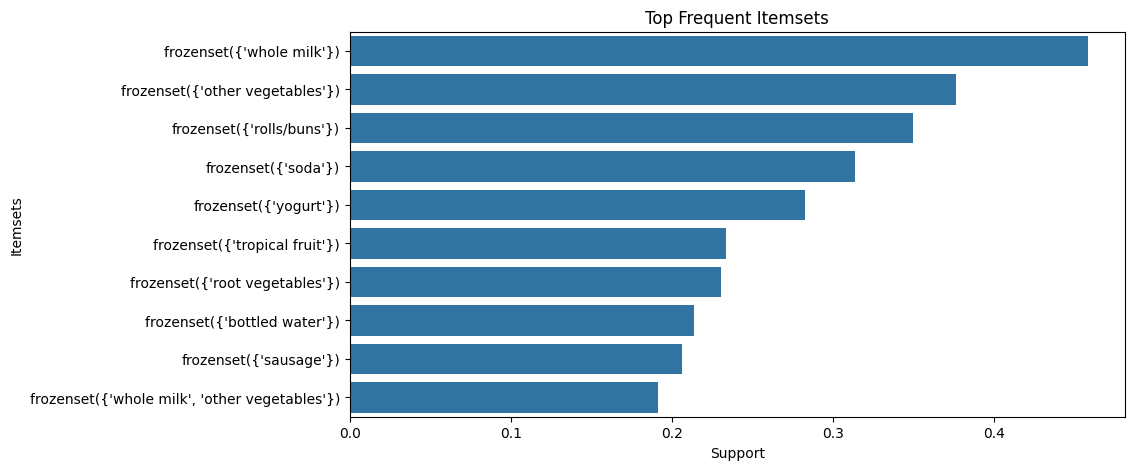

In [17]:
top_items = frequent_itemsets.sort_values("support", ascending=False).head(10)
plt.figure(figsize=(10,5))
sns.barplot(
    data=top_items,
    x="support",
    y=top_items["itemsets"].astype(str)  
)
plt.title("Top Frequent Itemsets")
plt.xlabel("Support")
plt.ylabel("Itemsets")
plt.show()

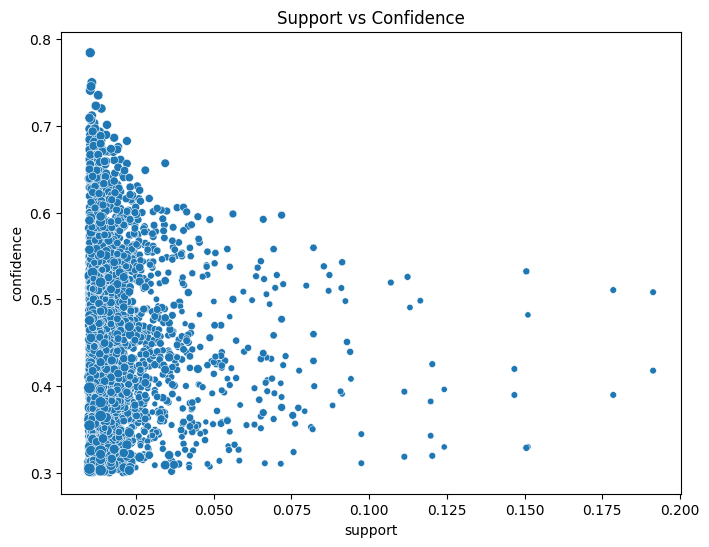

In [18]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=rules,
    x='support',
    y='confidence',
    size='lift',
    legend=False
)

plt.title("Support vs Confidence")
plt.show()

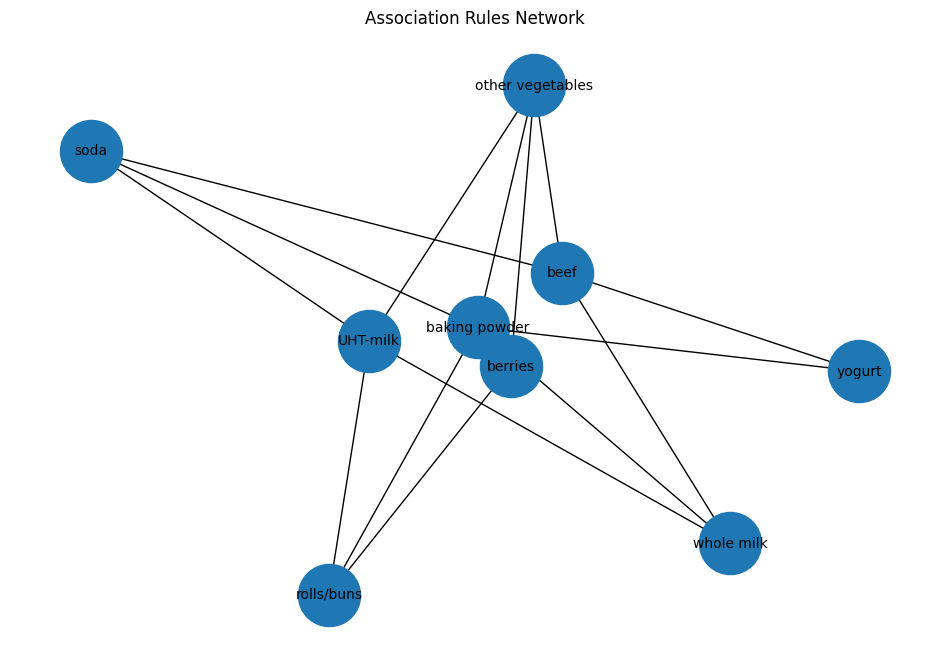

In [19]:
G = nx.DiGraph()

for _, row in rules.head(15).iterrows():
    for a in row['antecedents']:
        for c in row['consequents']:
            G.add_edge(a, c, weight=row['lift'])

plt.figure(figsize=(12,8))
pos = nx.spring_layout(G, k=1)

nx.draw_networkx_nodes(G, pos, node_size=2000)
nx.draw_networkx_edges(G, pos, arrows=True)
nx.draw_networkx_labels(G, pos, font_size=10)

plt.title("Association Rules Network")
plt.axis('off')
plt.show()

In [20]:
rules[['antecedents','consequents','support','confidence','lift']].head(15)

,antecedents,consequents,support,confidence,lift
30,(UHT-milk),(other vegetables),0.038994,0.496732,1.318979
38,(UHT-milk),(rolls/buns),0.031042,0.395425,1.130863
47,(UHT-milk),(soda),0.027450,0.349673,1.115406
52,(UHT-milk),(whole milk),0.040534,0.516340,1.126928
56,(baking powder),(other vegetables),0.015136,0.487603,1.294740
58,(baking powder),(rolls/buns),0.012314,0.396694,1.134493
61,(baking powder),(soda),0.012314,0.396694,1.265396
63,(baking powder),(whole milk),0.015136,0.487603,1.064209
65,(baking powder),(yogurt),0.011801,0.380165,1.343503
100,(beef),(other vegetables),0.050795,0.424893,1.128223
